In [1]:
import numpy as np
from io import StringIO

# proliferating e-anyons, m-anyons subthreshold

data_str1 = """ 0.596200 0.611500 0.635200 0.650900 0.666300 0.680100 0.701200 0.707900
0.595300 0.614300 0.621900 0.640800 0.663400 0.669500 0.693800 0.702700
0.594600 0.616400 0.636900 0.634200 0.661300 0.680600 0.694700 0.713300
0.590600 0.618700 0.637700 0.641200 0.672900 0.672800 0.696400 0.711800
0.580500 0.596200 0.628000 0.638300 0.654300 0.681600 0.694200 0.724900
0.578900 0.604700 0.616700 0.637300 0.661700 0.681700 0.699200 0.723100
0.575800 0.607800 0.619200 0.639500 0.667200 0.671600 0.707200 0.716400
0.578600 0.598400 0.624500 0.644600 0.671900 0.690300 0.694700 0.722600
0.574700 0.592500 0.620600 0.641100 0.662700 0.683000 0.706200 0.738500
0.563600 0.598000 0.612200 0.642300 0.667400 0.687800 0.712300 0.727500
0.574400 0.598900 0.624400 0.638400 0.667200 0.685800 0.705400 0.725600
0.574400 0.601500 0.621000 0.638800 0.657600 0.685700 0.700700 0.728200
0.569300 0.588200 0.611600 0.641900 0.657200 0.691700 0.710600 0.741200
0.557200 0.581700 0.615400 0.639300 0.659600 0.692100 0.708600 0.733700
0.555000 0.584800 0.620100 0.648900 0.668100 0.689100 0.712000 0.724500
0.564200 0.587800 0.612300 0.636300 0.657600 0.685400 0.710300 0.731400 """
data_str2 = """ 0.592700 0.607500 0.637500 0.653700 0.663200 0.687600 0.699300 0.711600
0.596400 0.610900 0.634200 0.643800 0.666800 0.674900 0.697300 0.709500
0.594200 0.614500 0.636100 0.644100 0.670400 0.679400 0.699000 0.718200
0.605500 0.613100 0.621200 0.650900 0.652000 0.684100 0.692600 0.716500
0.585400 0.598700 0.617100 0.645100 0.657300 0.685800 0.694800 0.714800
0.589000 0.608200 0.628400 0.652300 0.665400 0.677100 0.702800 0.713500
0.585200 0.608500 0.631400 0.647000 0.663500 0.686300 0.699000 0.717300
0.575000 0.606500 0.623700 0.642900 0.662000 0.681000 0.701200 0.717000
0.569500 0.582400 0.621800 0.639000 0.673600 0.678400 0.703800 0.731200
0.572100 0.591200 0.609400 0.644500 0.657600 0.686100 0.701600 0.727600
0.576700 0.590600 0.621300 0.633600 0.660600 0.686300 0.695200 0.721800
0.574400 0.607100 0.616700 0.632400 0.666300 0.688000 0.704800 0.726600
0.557700 0.579400 0.612800 0.635700 0.664500 0.690000 0.707400 0.732100
0.559600 0.581900 0.619000 0.643800 0.663500 0.693900 0.711800 0.734300
0.559600 0.584400 0.604600 0.630900 0.655000 0.685400 0.714700 0.731600
0.569900 0.584400 0.618700 0.640400 0.661800 0.693500 0.713300 0.736700 """
data_str3 = """ 0.602400 0.602800 0.631500 0.643100 0.662700 0.673900 0.696000 0.704800
0.592800 0.621100 0.632100 0.649600 0.670600 0.676800 0.691900 0.713400
0.591100 0.614600 0.624100 0.649900 0.660300 0.680900 0.683700 0.707700
0.589400 0.607800 0.629500 0.641800 0.667400 0.673400 0.691900 0.710800
0.588500 0.601400 0.613600 0.643200 0.666600 0.671200 0.697600 0.719600
0.585100 0.604400 0.626600 0.647100 0.660700 0.675100 0.695500 0.715000
0.579900 0.603600 0.624700 0.646900 0.655100 0.678400 0.694800 0.718900
0.585000 0.609900 0.622400 0.637900 0.661700 0.680300 0.694000 0.718000
0.576800 0.590900 0.617500 0.643200 0.652600 0.687900 0.700200 0.722300
0.568400 0.590200 0.620900 0.644100 0.653400 0.680000 0.711300 0.728000
0.573200 0.592100 0.619800 0.643100 0.660300 0.681100 0.702500 0.723300
0.578900 0.601000 0.623100 0.641800 0.666500 0.686400 0.709300 0.726600
0.564000 0.587800 0.609100 0.636700 0.662500 0.679500 0.710600 0.732400
0.562300 0.598700 0.618500 0.635700 0.656500 0.687500 0.708700 0.731000
0.561800 0.598700 0.611900 0.644300 0.661900 0.685600 0.712300 0.731300
0.556500 0.591700 0.610600 0.638900 0.661000 0.685800 0.707100 0.741200 """
data_str4 = """ 0.585400 0.610200 0.631600 0.645400 0.666600 0.681400 0.693000 0.716100
0.603500 0.610200 0.629800 0.640300 0.666900 0.677600 0.692700 0.714300
0.600700 0.611800 0.627800 0.651600 0.656300 0.676900 0.701300 0.709900
0.597900 0.608700 0.635300 0.650700 0.667300 0.679300 0.692600 0.710600
0.580700 0.602700 0.631300 0.644500 0.666700 0.684000 0.707400 0.719300
0.582100 0.599300 0.627300 0.641900 0.654900 0.682300 0.700500 0.710000
0.585400 0.600600 0.627900 0.643100 0.664600 0.687000 0.699400 0.715300
0.584000 0.603100 0.626700 0.641300 0.661500 0.686400 0.700100 0.721700
0.568700 0.604900 0.623200 0.639400 0.653000 0.688200 0.701100 0.724100
0.573700 0.599600 0.618800 0.642500 0.660300 0.678900 0.708500 0.722300
0.565100 0.596100 0.613500 0.629100 0.665500 0.688400 0.706200 0.728100
0.572400 0.594100 0.623400 0.637700 0.661600 0.691600 0.702300 0.720800
0.561200 0.586600 0.609400 0.638000 0.663600 0.691300 0.708300 0.729100
0.561000 0.587900 0.608000 0.643100 0.667200 0.685300 0.709700 0.727800
0.561200 0.578400 0.611800 0.639500 0.659100 0.683100 0.705200 0.732800
0.565000 0.588500 0.613700 0.645200 0.661600 0.690500 0.712700 0.726500 """
data_str5 = """ 0.595300 0.615800 0.635600 0.644000 0.667400 0.675900 0.693900 0.705800
0.594000 0.606300 0.632900 0.655700 0.664700 0.673600 0.697000 0.699600
0.591900 0.613900 0.635700 0.651800 0.663500 0.692100 0.689500 0.718900
0.595700 0.611500 0.636600 0.640700 0.671200 0.673400 0.686900 0.701300
0.578900 0.608300 0.616400 0.652300 0.656500 0.682600 0.698900 0.715700
0.578800 0.602300 0.627100 0.638400 0.661300 0.679800 0.701900 0.712600
0.578400 0.604600 0.622900 0.652800 0.673800 0.684000 0.702000 0.727000
0.585500 0.596900 0.616900 0.651000 0.666200 0.684900 0.690500 0.715300
0.563200 0.593700 0.615900 0.641300 0.668000 0.683800 0.705800 0.727800
0.568900 0.594800 0.620300 0.644000 0.656900 0.679900 0.708000 0.725700
0.574800 0.595000 0.612100 0.639200 0.658300 0.680700 0.700500 0.724700
0.563200 0.587700 0.616100 0.639300 0.659600 0.688600 0.707300 0.713900
0.567200 0.588400 0.607800 0.645200 0.663400 0.683300 0.704300 0.722400
0.557300 0.590800 0.619100 0.640200 0.651500 0.685200 0.701000 0.731700
0.563200 0.597300 0.615100 0.646800 0.668800 0.684100 0.707200 0.727700
0.559000 0.582400 0.618900 0.636600 0.664900 0.686500 0.716800 0.739200 """
data_str6 = """ 0.601000 0.626700 0.628300 0.639200 0.656500 0.677800 0.692000 0.722000
0.597500 0.608500 0.635500 0.645600 0.667900 0.691100 0.693400 0.711700
0.601900 0.614700 0.634700 0.641700 0.655300 0.679800 0.701500 0.709500
0.605400 0.621900 0.622600 0.648600 0.666800 0.677800 0.691700 0.706600
0.583200 0.606200 0.618900 0.644800 0.666500 0.687800 0.702500 0.719100
0.588600 0.608600 0.625000 0.643300 0.663600 0.687100 0.696500 0.714500
0.585300 0.597200 0.629900 0.653100 0.669800 0.686700 0.697600 0.715400
0.583500 0.600300 0.630900 0.637000 0.660000 0.686000 0.700500 0.720000
0.575700 0.596100 0.619500 0.642000 0.660800 0.684700 0.709700 0.721700
0.568000 0.595100 0.623900 0.646500 0.670200 0.680600 0.707300 0.725200
0.570400 0.596600 0.617400 0.640100 0.655900 0.685400 0.704400 0.722400
0.572300 0.583300 0.625300 0.642400 0.663500 0.679700 0.700800 0.712600
0.559400 0.595300 0.611700 0.638800 0.664500 0.687400 0.711200 0.737300
0.568900 0.586300 0.614500 0.647700 0.665700 0.686800 0.711000 0.731200
0.565300 0.593400 0.613000 0.630900 0.659700 0.680800 0.713000 0.746300
0.559300 0.586900 0.615700 0.649300 0.664500 0.687100 0.709300 0.735900 """
data_str7 = """ 0.594100 0.621400 0.637600 0.646500 0.659300 0.687400 0.693300 0.709700
0.592500 0.618700 0.631200 0.654500 0.661100 0.684700 0.704300 0.706600
0.587400 0.611100 0.625200 0.650800 0.657400 0.683400 0.698500 0.712200
0.592200 0.620900 0.626200 0.651000 0.667200 0.676900 0.687700 0.703800
0.582200 0.606100 0.624700 0.637500 0.667400 0.685400 0.694700 0.713700
0.576600 0.605200 0.623300 0.643900 0.662800 0.672700 0.696500 0.717900
0.584300 0.603800 0.626700 0.647000 0.668700 0.674500 0.701800 0.720500
0.580500 0.608300 0.624700 0.639200 0.655800 0.686800 0.691800 0.721900
0.574000 0.591700 0.617600 0.638400 0.653300 0.682300 0.709700 0.723900
0.564000 0.601700 0.619400 0.642200 0.659700 0.680300 0.712300 0.734900
0.577700 0.585000 0.624100 0.639600 0.659300 0.680000 0.710600 0.728200
0.573800 0.594500 0.619400 0.635700 0.663600 0.683600 0.699900 0.717600
0.565800 0.580900 0.608500 0.640900 0.667300 0.686700 0.710000 0.732000
0.557900 0.590500 0.607300 0.637100 0.665300 0.682000 0.714900 0.734700
0.562000 0.597700 0.613300 0.635500 0.667300 0.689700 0.700800 0.727400
0.564300 0.584000 0.610000 0.645000 0.662400 0.682100 0.701900 0.736100 """
data_str8 = """ 0.599300 0.620400 0.627000 0.644300 0.676100 0.681800 0.697100 0.707500
0.590200 0.611000 0.629900 0.649500 0.663300 0.683000 0.695400 0.698900
0.595900 0.614000 0.632300 0.650000 0.665900 0.670800 0.696900 0.709200
0.594300 0.618700 0.629700 0.660000 0.666800 0.676900 0.689100 0.704100
0.578900 0.599200 0.621900 0.649200 0.663200 0.673600 0.698200 0.718700
0.590500 0.602900 0.632000 0.640600 0.660100 0.679700 0.708300 0.712900
0.582000 0.600500 0.627000 0.644900 0.659800 0.683300 0.700600 0.716800
0.577200 0.604400 0.630900 0.643100 0.659700 0.682400 0.693100 0.714500
0.574600 0.594400 0.619900 0.653500 0.661700 0.686100 0.705200 0.723500
0.573000 0.590300 0.616300 0.633500 0.665700 0.682700 0.703900 0.731000
0.570300 0.591200 0.618200 0.640700 0.661100 0.684900 0.697100 0.728900
0.570900 0.590300 0.610700 0.637500 0.658200 0.682600 0.706400 0.717700
0.558000 0.579700 0.607700 0.636200 0.671400 0.691100 0.707600 0.734600
0.555400 0.577000 0.611600 0.637100 0.669000 0.689300 0.705200 0.731100
0.560800 0.586100 0.615500 0.635700 0.663200 0.686200 0.710900 0.734900
0.565800 0.592900 0.625800 0.646500 0.665100 0.684400 0.702900 0.727600 """
data_str9 = """ 0.593900 0.610900 0.624300 0.644700 0.665800 0.679000 0.694400 0.712400
0.593600 0.606300 0.631100 0.641900 0.653400 0.683400 0.692900 0.714800
0.595300 0.623300 0.623200 0.641700 0.667300 0.679800 0.696300 0.711900
0.595500 0.617300 0.627700 0.654600 0.662900 0.681800 0.692500 0.716400
0.586200 0.599900 0.626000 0.644600 0.660500 0.679900 0.704200 0.721500
0.589300 0.603200 0.623900 0.641400 0.660300 0.688400 0.704000 0.719300
0.583900 0.606500 0.625100 0.645500 0.663800 0.675300 0.698500 0.718800
0.583400 0.599900 0.618300 0.639700 0.663600 0.685800 0.700700 0.720900
0.567000 0.598400 0.616000 0.640500 0.662300 0.687900 0.703800 0.726800
0.577100 0.597900 0.622000 0.639100 0.659300 0.686400 0.703600 0.728100
0.581000 0.599700 0.617600 0.650700 0.666100 0.682100 0.703200 0.730600
0.568800 0.595900 0.620000 0.635200 0.665300 0.684200 0.711400 0.726600
0.562900 0.590800 0.621600 0.637700 0.673200 0.693900 0.707100 0.738000
0.562300 0.590200 0.618700 0.643500 0.656500 0.694900 0.712800 0.740900
0.569100 0.589300 0.626800 0.635900 0.668600 0.686400 0.710300 0.732600
0.563500 0.589100 0.614400 0.634300 0.659600 0.685000 0.710600 0.734800 """
data_str10= """ 0.607900 0.610500 0.638500 0.652700 0.665200 0.673900 0.699900 0.707400
0.595900 0.608700 0.631400 0.649900 0.666800 0.680400 0.699900 0.708500
0.595000 0.611900 0.627600 0.643300 0.659700 0.680500 0.690500 0.713200
0.602800 0.603300 0.632500 0.645100 0.664400 0.680100 0.706300 0.715800
0.578800 0.595500 0.621600 0.640900 0.660900 0.676700 0.707500 0.724000
0.585900 0.608000 0.627100 0.641400 0.659100 0.685200 0.699800 0.713500
0.600500 0.601500 0.630200 0.639700 0.657700 0.677500 0.703300 0.716700
0.591500 0.600400 0.625600 0.645500 0.664000 0.690800 0.705600 0.719600
0.576700 0.598700 0.622600 0.638900 0.663600 0.687900 0.713100 0.726900
0.572800 0.597400 0.621900 0.641500 0.651900 0.684000 0.694700 0.724400
0.569100 0.591600 0.612800 0.639900 0.661400 0.681200 0.704100 0.718800
0.577900 0.594800 0.619200 0.649600 0.664900 0.679500 0.697100 0.719500
0.562600 0.588400 0.611200 0.643000 0.667800 0.683200 0.708100 0.736800
0.565400 0.584900 0.608200 0.635300 0.662800 0.691500 0.707900 0.732200
0.561900 0.591800 0.607300 0.639400 0.666700 0.682100 0.704600 0.729900
0.551700 0.589500 0.611400 0.636400 0.671200 0.684000 0.718300 0.738200 """

run1 = np.loadtxt(StringIO(data_str1))
run2 = np.loadtxt(StringIO(data_str2))
run3 = np.loadtxt(StringIO(data_str3))
run4 = np.loadtxt(StringIO(data_str4))
run5 = np.loadtxt(StringIO(data_str5))
run6 = np.loadtxt(StringIO(data_str6))
run7 = np.loadtxt(StringIO(data_str7))
run8 = np.loadtxt(StringIO(data_str8))
run9 = np.loadtxt(StringIO(data_str9))
run10= np.loadtxt(StringIO(data_str10))

runs = np.stack([run1, run2, run3, run4, run5, run6, run7, run8, run9, run10])

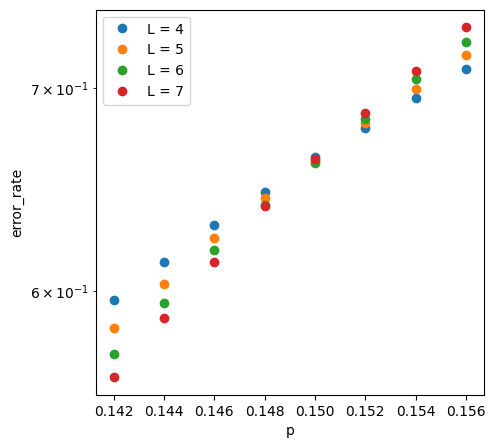

In [2]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

p = [0.142, 0.144, 0.146, 0.148, 0.15, 0.152, 0.154, 0.156]
L = [4, 5, 6, 7]

error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

plt.figure(figsize=(5, 5))
for l in range(len(L)):
    plt.plot(p, error_rate[l], 'o', label=f'L = {L[l]}')
    
plt.yscale('log')
plt.xlabel('p')
plt.ylabel('error_rate')
plt.legend()
plt.show()

In [6]:
from scipy.optimize import curve_fit

p = np.tile(np.array([0.142, 0.144, 0.146, 0.148, 0.15, 0.152, 0.154, 0.156]), 4)
L = np.repeat(np.array([4,5,6,7]), 8)
rate = error_rate.flatten()
n = 4 * 10**4
rate_error = np.array([])
for i in range(len(p)):
    se = (rate[i]*(1-rate[i])/n)**(1/2)
    rate_error = np.append(rate_error, se)

In [7]:
# Define the model
def model(pL, pc, nu, A, B, C):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [ 0.15002755  1.40616239  0.66330582  3.01921596 -5.28968915]
Parameter standard deviations: [3.02831472e-04 8.87278192e-02 2.99770390e-03 2.34996916e-01
 2.12383882e+00]


np.float64(6.820274538731346)

In [8]:
# Define the model
def model(pL, pc, nu, A, B, C, D):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + D*((p-pc)**3)*(L**(3/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, p0=[0.2, 1.5, 0.25, 0, 0, 0], full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [ 0.15003298  1.41628113  0.66332528  3.03456881 -5.11110831 27.07978248]
Parameter standard deviations: [3.06158903e-04 1.04461618e-01 3.00517775e-03 2.48415978e-01
 2.37894282e+00 1.47866914e+02]


np.float64(6.7070317374873625)

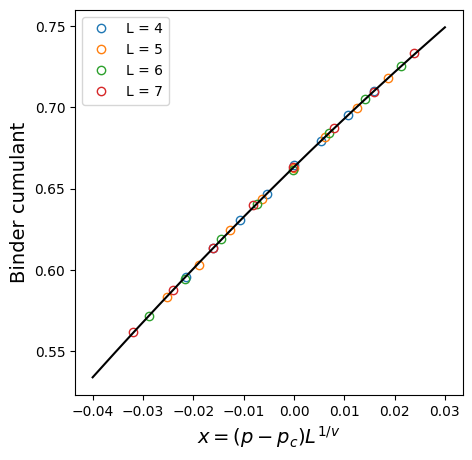

In [12]:
pc = 0.15002755
nu = 1.40616239
A = 0.66330582
B = 3.01921596
C = -5.28968915
# D = -149.66927112
p = [0.142, 0.144, 0.146, 0.148, 0.15, 0.152, 0.154, 0.156]
L = [4, 5, 6, 7]
error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

x = np.zeros((len(L), len(p)))
plt.figure(figsize=(5, 5))
for l in range(len(L)):
    for i in range(len(p)):
        x[l][i] = (p[i]-pc) * (L[l]**(1/nu))
    plt.plot(x[l], error_rate[l], 'o', markerfacecolor='none', label=f'L = {L[l]}')
x_data = np.linspace(-0.04, 0.03, 1000)
y_data = A + B*x_data + C*(x_data**2) #+D*(x_data**3)
plt.plot(x_data, y_data, color = 'k')

#ax = plt.gca()
#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)

#plt.yscale('log')
plt.xlabel('$x=(p-p_c)L^{1/v}$', fontsize=14)
plt.ylabel('Binder cumulant', fontsize=14)
plt.legend()
#plt.savefig('modified-D4.png', dpi=600, bbox_inches='tight')
plt.show()